# 05 · ¿Qué mejoras de contexto acompañan la mejora del desempeño? — Asociaciones entre provincias

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/santiagoriverti/analisis_pruebas_aprender/blob/main/05_asociaciones.ipynb)

**Pregunta:** las provincias que más mejoraron su contexto educativo (más libros, internet, madres más educadas, menos
repitencia, más docentes por alumno, menos cargos sin cubrir…) ¿son las que más mejoraron en las pruebas APRENDER?

**Método (descriptivo, sin econometría):**
1. **Desempeño:** % Satisfactorio + Avanzado por provincia en Lengua y Matemática, en las cohortes comparables
   (Primaria 6°: 2016·18·21·23·25; Secundaria 5-6°: 2016·17·19·22·24).
2. **Contexto:** indicadores del cuestionario del estudiante (misma receta que el 04) y del **Relevamiento Anual** (docentes,
   vacantes, titulares, sobreedad, repitencia, abandono).
3. **Ventanas comparables:** cada indicador se mide entre dos años en los que su pregunta es equivalente, y el desempeño se
   mide **en los mismos dos años**.
4. **Asociación:** correlación de rangos de **Spearman (ρ)** entre las 24 provincias:
   - **cambio vs cambio** (lo que responde la pregunta);
   - **cambio vs cambio frente a pares**: el cambio de desempeño menos el cambio medio de las provincias de su tercil de
     nivel inicial (criterio del 03). Controla la **convergencia**: las provincias que parten más abajo mejoran más (o caen
     menos), y eso puede crear correlaciones engañosas;
   - **nivel vs nivel** en el año final (referencia: qué se asocia con *dónde* se rinde mejor).
5. **Azar:** valor *p* por **permutaciones** (10.000) y *q* de **Benjamini-Hochberg** por hacer ~100 comparaciones: con
   24 provincias hace falta |ρ| ≳ 0,4 para distinguirse del azar, y ~5 % de las comparaciones dan "significativas" por casualidad.

**Límites:** son **24 provincias y datos agregados** (una asociación entre provincias no dice nada de cada estudiante);
ventanas cortas; cambios de cuestionario (ver 04); en Secundaria cambia **quién llega a rendir**; faltan factores no medidos
(participación en la prueba, días de clase, pandemia, programas provinciales). **Asociación no es causa.**

Requiere haber corrido antes `00_consolidacion.ipynb` (lee de *Mi unidad/`pruebas_aprender`*). No necesita el 01 a 04.

---
## 0 · Setup y carga

In [1]:
import os, re, glob, shutil, textwrap, unicodedata
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import pyarrow.dataset as pads

def in_colab():
    try:
        import google.colab  # noqa
        return True
    except ImportError:
        return False

if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    OUT = '/content/drive/MyDrive/pruebas_aprender/parquet'
else:
    OUT = os.path.join(os.getcwd(), 'datos_consolidados')
assert os.path.isdir(os.path.join(OUT, 'aprender_long')), (
    f'No encuentro el dataset en {OUT}. Corré primero 00_consolidacion.ipynb.')

# Paleta validada (igual que 03 y 04): azul/rojo divergente con gris neutro al medio
SUPERFICIE, TINTA, TINTA_2, TENUE, GRILLA, EJE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
AZUL, NARANJA, ROJO, NEUTRO = '#2a78d6', '#eb6834', '#e34948', '#f0efec'
DIVERGENTE = LinearSegmentedColormap.from_list('divergente', [ROJO, NEUTRO, AZUL])
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': SUPERFICIE, 'axes.facecolor': SUPERFICIE, 'savefig.facecolor': SUPERFICIE,
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans', 'Arial'],
    'text.color': TINTA, 'axes.labelcolor': TINTA_2, 'axes.edgecolor': EJE, 'axes.titlecolor': TINTA,
    'xtick.color': TENUE, 'ytick.color': TINTA_2, 'axes.grid': True, 'grid.color': GRILLA, 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.axisbelow': True})

GRAF = os.path.abspath('graficos_asociaciones'); os.makedirs(GRAF, exist_ok=True)
def guardar(fig, nombre):
    fig.savefig(os.path.join(GRAF, nombre + '.png'), dpi=300, bbox_inches='tight')
    return fig
def nota(fig, texto, y=-0.01):
    fig.text(0.01, y, texto, fontsize=8, color=TENUE, ha='left', va='top')
FUENTE = ('Fuente: Pruebas APRENDER y Relevamiento Anual (Secretaría de Educación). Correlación de rangos de Spearman entre '
          '24 provincias; asociación, no causa.')
print('Datos consolidados en:', OUT)
print('Salidas (gráficos 300 dpi + Excel) en:', GRAF)

Datos consolidados en: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\datos_consolidados
Salidas (gráficos 300 dpi + Excel) en: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_asociaciones


---
## 1 · Funciones: desempeño, cuestionario y Relevamiento Anual

In [2]:
def _n(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode().lower()
    return re.sub(r'[^a-z0-9]+', ' ', s).strip()
PROV_ALIAS = {'buenos aires': 'Buenos Aires', 'ciudad autonoma de buenos aires': 'CABA', 'ciudad de buenos aires': 'CABA',
              'tierra del fuego': 'Tierra del Fuego', 'tierra del fuego antartida e islas del atlantico sur': 'Tierra del Fuego'}
def norm_prov(s):
    return PROV_ALIAS.get(_n(s), str(s).strip())

COHORTES = {'Primaria 6°':     dict(nivel='Primaria',   grado='6 grado', anios=[2016, 2018, 2021, 2023, 2025]),
            'Secundaria 5-6°': dict(nivel='Secundaria', grado='5-6 año', anios=[2016, 2017, 2019, 2022, 2024])}
AREAS = ['Lengua', 'Matematica']
def archivos(anio):
    return sorted(glob.glob(os.path.join(OUT, 'aprender_long', f'anio={anio}', '*.parquet')))

# ---- Desempeño: % Satisfactorio + Avanzado por provincia (misma receta que 02 y 03)
ORDEN4 = ['Por debajo del básico', 'Básico', 'Satisfactorio', 'Avanzado']
def harmonizar_nivel(op):
    t = _n(op)
    if 'por debajo' in t: return 'Por debajo del básico'
    if t == 'basico': return 'Básico'
    if 'satisfactorio' in t: return 'Satisfactorio'
    if 'avanzado' in t: return 'Avanzado'
    return None
filas = []
for coh, c in COHORTES.items():
    for anio in c['anios']:
        f = ((pads.field('tipo_variable') == 'desempeño') & (pads.field('cobertura') == 'Censal')
             & (pads.field('nivel') == c['nivel']) & (pads.field('grado') == c['grado']))
        d = pads.dataset(archivos(anio), format='parquet').to_table(filter=f, columns=['area', 'jurisdiccion', 'variable', 'valor']).to_pandas()
        d = d[d.area.isin(AREAS)].copy()
        d['nd'] = d.variable.str.split('_', n=1).str[1].map(harmonizar_nivel)
        d = d.dropna(subset=['nd']); d['provincia'] = d.jurisdiccion.map(norm_prov)
        t = d.groupby(['area', 'provincia', 'nd']).valor.sum().unstack().reindex(columns=ORDEN4).fillna(0)
        sa = (100 * (t['Satisfactorio'] + t['Avanzado']) / t.sum(axis=1)).rename('pct').reset_index()
        filas.append(sa.assign(cohorte=coh, anio=anio))
DES = pd.concat(filas).pivot_table(index=['cohorte', 'area', 'provincia'], columns='anio', values='pct')
assert DES.groupby(['cohorte', 'area']).size().eq(24).all()

# ---- Cuestionario del estudiante (Solo CC censal), igual que el 04
BLANCOS = {'Blanco', 'No_disponible', 'Multimarca', 'Dato_faltante'}
NO_SABE = re.compile(r'^(\d+_)?No_s[eé]$')
_cache_cc = {}
def cuestionario(coh, anio, codigos):
    k = (coh, anio)
    if k not in _cache_cc:
        c = COHORTES[coh]
        f = ((pads.field('area') == 'Solo CC') & (pads.field('cobertura') == 'Censal')
             & (pads.field('nivel') == c['nivel']) & (pads.field('grado') == c['grado']))
        d = pads.dataset(archivos(anio), format='parquet').to_table(filter=f, columns=['jurisdiccion', 'variable', 'valor']).to_pandas()
        sp = d.variable.str.split('_', n=1)
        d['codigo'], d['opcion'] = sp.str[0], sp.str[1]
        d = d[d.codigo.isin(codigos)].copy()
        d['provincia'] = d.jurisdiccion.map(norm_prov)
        _cache_cc[k] = d.drop(columns=['jurisdiccion', 'variable'])
    return _cache_cc[k]

def S(codigo, **kw):
    return dict(codigo=codigo, **kw)

def pct_provincia(d, s):
    """% de estudiantes por provincia (sin blancos ni "No sé"); asserts si una opción no existe."""
    x = d[d.codigo == s['codigo']]
    assert len(x), f"código {s['codigo']} sin datos"
    op = x.opcion
    if s.get('prefijo'):
        m = op.str.startswith(s['prefijo']); x, op = x[m], op[m].str[len(s['prefijo']):]
    valido = ~op.isin(BLANCOS) & ~op.str.match(NO_SABE)
    ops = set(op[valido])
    if 'excluir' in s:
        assert set(s['excluir']) <= ops, f"{s['codigo']}: opciones a excluir inexistentes {set(s['excluir']) - ops}"
        num = ~op.isin(s['excluir'])
    else:
        assert set(s['num']) <= ops, f"{s['codigo']} {s.get('prefijo') or ''}: opciones inexistentes {set(s['num']) - ops}"
        num = op.isin(s['num'])
    num &= valido
    t = x.assign(num=x.valor.where(num, 0.0), den=x.valor.where(valido, 0.0)).groupby('provincia')[['num', 'den']].sum()
    return 100 * t.num / t.den

# ---- Relevamiento Anual por provincia y año (docentes, vacantes, titulares, trayectorias)
def cargar_ra(base): return pd.read_parquet(os.path.join(OUT, 'ra', f'ra_{base}.parquet'))
def num(df, cols): return df[cols].apply(pd.to_numeric, errors='coerce').astype('float64').fillna(0)
def por_prov(df, cols):
    return num(df, cols).assign(anio=df.anio, provincia=df.provincia.map(norm_prov)).groupby(['provincia', 'anio']).sum()
PRIM, SEC = range(1, 7), range(7, 13)
_m = por_prov(cargar_ra('matricula'), [f'_{i}' for i in range(1, 13)] + [f's_{i}' for i in range(1, 13)])
_t = por_prov(cargar_ra('trayectoria'), [f'{p}_{i}' for p in ['inicial', 'nopromo', 'ssp'] for i in range(1, 13)])
_c = por_prov(cargar_ra('cargos'), ['pri_fte_cub', 'pri_fte_ncub', 'pri_apo_cub', 'sec_fte_cub', 'sec_hs_docente_cub', 'sec_hs_docente_ncub'])
sm = lambda df, p, r: df[[f'{p}_{i}' for i in r]].sum(axis=1)
RA = {
 'Primaria 6°': pd.DataFrame({
    'alumnos por maestro frente a alumnos': sm(_m, '', PRIM) / _c.pri_fte_cub,
    'maestros de apoyo cada 1.000 alumnos': 1000 * _c.pri_apo_cub / sm(_m, '', PRIM),
    '% cargos frente a alumnos sin cubrir': 100 * _c.pri_fte_ncub / (_c.pri_fte_cub + _c.pri_fte_ncub),
    '% sobreedad 1°–6°': 100 * sm(_m, 's', PRIM) / sm(_m, '', PRIM),
    'repitencia 1°–6° (ciclo anterior)': 100 * sm(_t, 'nopromo', PRIM) / sm(_t, 'inicial', PRIM)}),
 'Secundaria 5-6°': pd.DataFrame({
    'horas docentes por alumno': _c.sec_hs_docente_cub / sm(_m, '', SEC),
    'cargos frente a alumnos cada 100 alumnos': 100 * _c.sec_fte_cub / sm(_m, '', SEC),
    '% horas docentes sin cubrir': 100 * _c.sec_hs_docente_ncub / (_c.sec_hs_docente_cub + _c.sec_hs_docente_ncub),
    '% sobreedad 7°–12°': 100 * sm(_m, 's', SEC) / sm(_m, '', SEC),
    'repitencia 7°–12° (ciclo anterior)': 100 * sm(_t, 'nopromo', SEC) / sm(_t, 'inicial', SEC),
    'abandono 7°–12° (ciclo anterior)': 100 * sm(_t, 'ssp', SEC) / sm(_t, 'inicial', SEC)})}
# % titulares entre los cargos frente a alumnos (Cargos Bis: filtrar tipo y categoría; `total` mezcla unidades)
b = cargar_ra('cargos_bis')[['anio', 'provincia', 'nivel', 'tipo', 'categoria', 'planta_tipo', 'total']]
for col in ['nivel', 'tipo', 'categoria', 'planta_tipo']: b[col] = b[col].astype(str).str.strip()
b = b[(b.tipo == 'Cargos') & (b.categoria == 'Frente a Alumnos') & b.nivel.isin(['Primaria', 'Secundaria'])].copy()
b['total'] = pd.to_numeric(b.total, errors='coerce').fillna(0); b['provincia'] = b.provincia.map(norm_prov)
tit = b.pivot_table(index=['provincia', 'anio'], columns=['nivel', 'planta_tipo'], values='total', aggfunc='sum').fillna(0)
for niv, coh in [('Primaria', 'Primaria 6°'), ('Secundaria', 'Secundaria 5-6°')]:
    ti, it = tit[(niv, 'Planta Funcional - Titular')], tit[(niv, 'Planta Funcional - Interinos')]
    RA[coh]['% titulares en cargos frente a alumnos'] = (100 * ti / (ti + it)).reindex(RA[coh].index)
for coh in RA:
    assert RA[coh].groupby('anio').size().loc[2016:2025].eq(24).all(), coh
print('Desempeño por provincia:', DES.shape, '· indicadores RA:', {k: v.shape[1] for k, v in RA.items()})

Desempeño por provincia: (96, 9) · indicadores RA: {'Primaria 6°': 6, 'Secundaria 5-6°': 7}


---
## 2 · Ventanas comparables
Cada fila define un indicador y **dos años en los que su pregunta es equivalente** (ver la sección 2 del 04). El desempeño se
mide en esos mismos años. Las ventanas marcadas *salto de cuestionario* (Primaria 2023→2025) se muestran para
transparencia, pero en el 04 se vio que el cambio es parejo en todas las provincias (probable efecto del instrumento).
Los indicadores del RA se miden en la ventana larga de cada cohorte y en la de los dos últimos operativos.

In [3]:
MADRE_SEC_23 = {'Secundaria_completa', 'Terciario_universitario_posgrado_incompleto', 'Terciario_universitario_posgrado_completo'}
LIB50 = {'De_51_a_100_libros', 'Más_de_100_libros'}
# (cohorte, tema, indicador, especificación año inicial, especificación año final, nota)
VENTANAS = {
 'Primaria 6°': [
  ('Trayectoria', 'Repitió algún grado', {2016: S('Ap12', excluir={'1_Nunca'}), 2025: S('ap07', excluir={'No'})}, ''),
  ('Trayectoria', 'Fue al jardín desde sala de 3 o antes', {2016: S('Ap11', num={'1_Sí_fui_al_jardín_antes_de_los_cuatro_años'}), 2025: S('ap06', num={'Sí_fui_al_jardín_desde_sala_de_3_o_antes'})}, ''),
  ('Hogar', 'Madre con secundaria completa o más', {2016: S('Ap7', num={'Fue_a_la_escuela_secundaria_y_la_completó', 'Estudio_el_nivel_terciario_o_en_una_universidad'}),
      2021: S('Nivel', prefijo='Ed_Madre_', num={'Secundario_completo', 'Terciario_Universitario_incompleto', 'Terciario_Universitario_completo', 'Posgrado_especialización_maestría_doctorado_etc'})}, 'con "No sé"'),
  ('Hogar', 'Madre con secundaria completa o más', {2023: S('Nivel', prefijo='Ed_Madre_', num=MADRE_SEC_23), 2025: S('Nivel', prefijo='Ed_Madre_', num=MADRE_SEC_23)}, 'salto de cuestionario'),
  ('Hogar', 'Madre con terciario o universitario completo', {2018: S('ap9', num={'Universitario_o_terciario_completo'}),
      2021: S('Nivel', prefijo='Ed_Madre_', num={'Terciario_Universitario_completo', 'Posgrado_especialización_maestría_doctorado_etc'})}, ''),
  ('Hogar', 'Más de 50 libros en el hogar', {2018: S('ap8', num=LIB50), 2021: S('ap15', num=LIB50)}, ''),
  ('Hogar', 'Más de 50 libros en el hogar', {2023: S('ap10', num=LIB50), 2025: S('ap24', num={'51_a_100_libros', 'Más_de_100_libros'})}, 'salto de cuestionario'),
  ('Acceso digital', 'Internet en el hogar', {2016: S('Ap28j', num={'Si'}), 2023: S('ap09d', num={'Sí'})}, 'redacción similar'),
  ('Acceso digital', 'Computadora en el hogar', {2018: S('ap7c', num={'Sí'}), 2023: S('ap09i', num={'Sí'})}, ''),
  ('Acceso digital', 'Celular propio', {2016: S('Ap29', num={'1_Sí'}), 2023: S('ap11', num={'Sí'})}, ''),
  ('Trabajo y cuidados', 'Ayuda a familiares en su trabajo', {2018: S('ap14', num={'Sí'}), 2021: S('ap20a', num={'Si'})}, ''),
  ('Trabajo y cuidados', 'Cuida a hermanos u otros familiares', {2018: S('ap13a', excluir={'Nunca'}), 2021: S('ap19a', excluir={'Nunca'})}, ''),
 ],
 'Secundaria 5-6°': [
  ('Trayectoria', 'Repitió en la primaria', {2016: S('Ap15', excluir={'1_Nunca'}), 2024: S('ap25a', excluir={'No'})}, ''),
  ('Trayectoria', 'Repitió en el ciclo básico', {2019: S('ap25', prefijo='02_', excluir={'No'}), 2024: S('ap25b', excluir={'No'})}, 'sin Chubut'),
  ('Trayectoria', 'Fue al jardín desde sala de 3 o antes', {2016: S('Ap14', num={'1_Sí_fui_al_jardín_antes_de_los_cuatro_años'}), 2024: S('ap24', num={'Sí_desde_sala_de_3_o_antes'})}, ''),
  ('Trayectoria', 'Con sobreedad (1 año o más)', {2019: S('sobreedad', excluir={'Edad_teórica_para_el_grado_17_años_al_30_de_junio', 'Menos_de_17_años'}),
      2024: S('sobreedad', excluir={'Edad_teórica_para_el_año_17_años_al_30_de_junio', 'Menores_de_17_años'})}, 'sin Chubut'),
  ('Hogar', 'Madre con secundaria completa o más', {2016: S('Ap7', num={'4_Terminó_la_escuela_secundaria', '5_Tiene_estudios_terciarios', '6_Tiene_estudios_universitarios'}),
      2024: S('Nivel', prefijo='Ed_Madre_', num={'Secundaria_completo', 'Terciariouniversitarioposgrado_incompleto', 'Terciariouniversitarioposgrado_completo'})}, ''),
  ('Hogar', 'Madre con terciario o universitario completo', {2017: S('ap10', num={'Universitario_o_terciario_completo'}),
      2024: S('Nivel', prefijo='Ed_Madre_', num={'Terciariouniversitarioposgrado_completo'})}, ''),
  ('Hogar', 'Más de 50 libros en el hogar', {2017: S('ap9', num=LIB50), 2019: S('ap15', num=LIB50)}, ''),
  ('Hogar', 'Más de 50 libros en el hogar', {2022: S('ap15', num=LIB50), 2024: S('ap19', num=LIB50)}, ''),
  ('Acceso digital', 'Internet en el hogar', {2017: S('ap7d', num={'Sí'}), 2024: S('ap16k', num={'Sí'})}, ''),
  ('Acceso digital', 'Computadora en el hogar', {2017: S('ap8b', num={'Sí'}), 2024: S('ap16g', num={'Sí'})}, ''),
  ('Acceso digital', 'Computadora en el hogar', {2022: S('ap12g', num={'Sí'}), 2024: S('ap16g', num={'Sí'})}, ''),
  ('Trabajo y cuidados', 'Trabaja para un empleador o no familiar', {2022: S('ap19a', excluir={'No_realicé_esta_tarea'}), 2024: S('ap22b', excluir={'No_hice_estas_actividades'})}, ''),
  ('Trabajo y cuidados', 'Cuida a familiares sin ayuda', {2022: S('ap18b', excluir={'No_realicé_esta_tarea'}), 2024: S('ap21b', excluir={'No_hice_estas_actividades'})}, ''),
 ]}
VENTANAS_RA = {'Primaria 6°': [(2016, 2025), (2023, 2025)], 'Secundaria 5-6°': [(2016, 2024), (2022, 2024)]}

filas, ind_prov = [], {}
for coh, lista in VENTANAS.items():
    for anio in COHORTES[coh]['anios']:
        codigos = {sp[anio]['codigo'] for _, _, sp, _ in lista if anio in sp}
        d = cuestionario(coh, anio, codigos) if codigos else None
        for tema, nombre, sp, nota_v in lista:
            if anio in sp:
                (y0, y1) = sorted(sp)
                ind_prov.setdefault((coh, tema, nombre, y0, y1, nota_v), {})[anio] = pct_provincia(d, sp[anio])
    for tema_ra in RA[coh].columns:
        for y0, y1 in VENTANAS_RA[coh]:
            s = RA[coh][tema_ra].unstack('anio')
            ind_prov[(coh, 'Relevamiento Anual', tema_ra, y0, y1, '')] = {y0: s[y0], y1: s[y1]}
print('Ventanas:', len(ind_prov), '· por cohorte:', pd.Series([k[0] for k in ind_prov]).value_counts().to_dict())

Ventanas: 51 · por cohorte: {'Secundaria 5-6°': 27, 'Primaria 6°': 24}


---
## 3 · Correlaciones
Para cada ventana y área: ρ de Spearman entre el **cambio del indicador** y el **cambio del desempeño** (pp), el mismo ρ con
el cambio **frente a pares** (tercil de nivel inicial) y ρ **nivel vs nivel** en el año final. *p* por permutaciones (10.000,
semilla fija) y *q* de Benjamini-Hochberg sobre las comparaciones cambio vs cambio.

In [4]:
N_PERM = 10_000
rng = np.random.default_rng(20260916)
PERM = {n: np.argsort(rng.random((N_PERM, n)), axis=1) for n in (23, 24)}   # permutaciones fijas por tamaño

def spearman(x, y):
    """ρ de Spearman y p bilateral por permutaciones (x, y alineados, sin NaN)."""
    rx = (x.rank().values - (len(x) + 1) / 2); ry = (y.rank().values - (len(y) + 1) / 2)
    rx, ry = rx / np.sqrt((rx ** 2).sum()), ry / np.sqrt((ry ** 2).sum())
    r = float(rx @ ry)
    perm = ry[PERM[len(x)]] @ rx
    return r, float((np.abs(perm) >= abs(r) - 1e-12).mean())

def frente_a_pares(inicial, delta):
    ter = pd.qcut(inicial.rank(method='first'), 3, labels=False)
    return delta - delta.groupby(ter).transform('mean')

res, pares = [], {}
for (coh, tema, nombre, y0, y1, nota_v), v in ind_prov.items():
    d_ind = (v[y1] - v[y0]).dropna()
    for area in AREAS:
        des = DES.loc[(coh, area)]
        idx = d_ind.index.intersection(des.index)
        d_des = (des[y1] - des[y0])[idx]
        r, p = spearman(d_ind[idx], d_des)
        rp, pp = spearman(d_ind[idx], frente_a_pares(des[y0][idx], d_des))
        rn, pn = spearman(v[y1][idx], des[y1][idx])
        res.append(dict(cohorte=coh, tema=tema, indicador=nombre, ventana=f'{y0}→{y1}', nota=nota_v, area=area, provincias=len(idx),
                        cambio_medio_indicador=d_ind[idx].mean(), cambio_medio_desempeno=d_des.mean(),
                        rho_cambio=r, p_cambio=p, rho_frente_pares=rp, p_frente_pares=pp, rho_nivel_final=rn, p_nivel_final=pn))
        pares[(coh, nombre, f'{y0}→{y1}', area)] = pd.DataFrame({'cambio_indicador': d_ind[idx], 'cambio_desempeno': d_des})
RES = pd.DataFrame(res)
orden = RES.p_cambio.rank(method='first')
q = RES.p_cambio * len(RES) / orden
RES['q_cambio'] = q[orden.sort_values(ascending=False).index].cummin().reindex(RES.index).clip(upper=1)
print(f'Comparaciones cambio vs cambio: {len(RES)} · p < 0,05: {(RES.p_cambio < 0.05).sum()} '
      f'(esperables por azar: {0.05 * len(RES):.0f}) · q < 0,10: {(RES.q_cambio < 0.10).sum()}')

ANCHO = RES.pivot_table(index=['cohorte', 'tema', 'indicador', 'ventana', 'nota'], columns='area',
                        values=['rho_cambio', 'p_cambio', 'q_cambio', 'rho_frente_pares', 'rho_nivel_final'], aggfunc='first', sort=False)
ANCHO = ANCHO.reindex(columns=['rho_cambio', 'p_cambio', 'q_cambio', 'rho_frente_pares', 'rho_nivel_final'], level=0)
pd.set_option('display.max_rows', 200)
display(ANCHO.round(2))

Comparaciones cambio vs cambio: 102 · p < 0,05: 11 (esperables por azar: 5) · q < 0,10: 5


rho_cambio  \
area                                                                                                                Lengua   
cohorte         tema               indicador                                    ventana   nota                               
Primaria 6°     Trayectoria        Repitió algún grado                          2016→2025                            -0.29   
                                   Fue al jardín desde sala de 3 o antes        2016→2025                             0.12   
                Hogar              Madre con secundaria completa o más          2016→2021 con "No sé"                -0.01   
                                                                                2023→2025 salto de cuestionario       0.18   
                                   Madre con terciario o universitario completo 2018→2021                            -0.27   
                                   Más de 50 libros en el hogar                 2018→2021                             0.12   
                                                                                2023→2025 salto de cuestionario       0.14   
                Acceso digital     Internet en el hogar                         2016→2023 redacción similar          -0.07   
                                   Celular propio                               2016→2023                            -0.41   
                                   Computadora en el hogar                      2018→2023                             0.04   
                Trabajo y cuidados Ayuda a familiares en su trabajo             2018→2021                            -0.35   
                                   Cuida a hermanos u otros familiares          2018→2021                             0.07   
                Relevamiento Anual alumnos por maestro frente a alumnos         2016→2025                            -0.11   
                                                                                2023→2025                             0.32   
                                   maestros de apoyo cada 1.000 alumnos         2016→2025                            -0.02   
                                                                                2023→2025                            -0.08   
                                   % cargos frente a alumnos sin cubrir         2016→2025                             0.58   
                                                                                2023→2025                             0.17   
                                   % sobreedad 1°–6°                            2016→2025                            -0.47   
                                                                                2023→2025                             0.30   
                                   repitencia 1°–6° (ciclo anterior)            2016→2025                            -0.01   
                                                                                2023→2025                             0.17   
                                   % titulares en cargos frente a alumnos       2016→2025                             0.14   
                                                                                2023→2025                            -0.09   
Secundaria 5-6° Trayectoria        Fue al jardín desde sala de 3 o antes        2016→2024                             0.02   
                                   Repitió en la primaria                       2016→2024                            -0.18   
                                   Repitió en el ciclo básico                   2019→2024 sin Chubut                  0.37   
                                   Con sobreedad (1 año o más)                  2019→2024 sin Chubut                  0.22   
                Hogar              Madre con secundaria completa o más          2016→2024                             0.17   
                                   Madre con terciario o universitario completo 

---
## A · Mapa de correlaciones
Azul = las provincias que más aumentaron el indicador son las que más mejoraron (o menos cayeron); rojo = al revés.
`*` p < 0,05 · `**` además q < 0,10 (resiste la corrección por comparaciones múltiples). Las dos últimas columnas son la
referencia **nivel vs nivel**: muestran con qué se asocia *dónde* se rinde mejor.

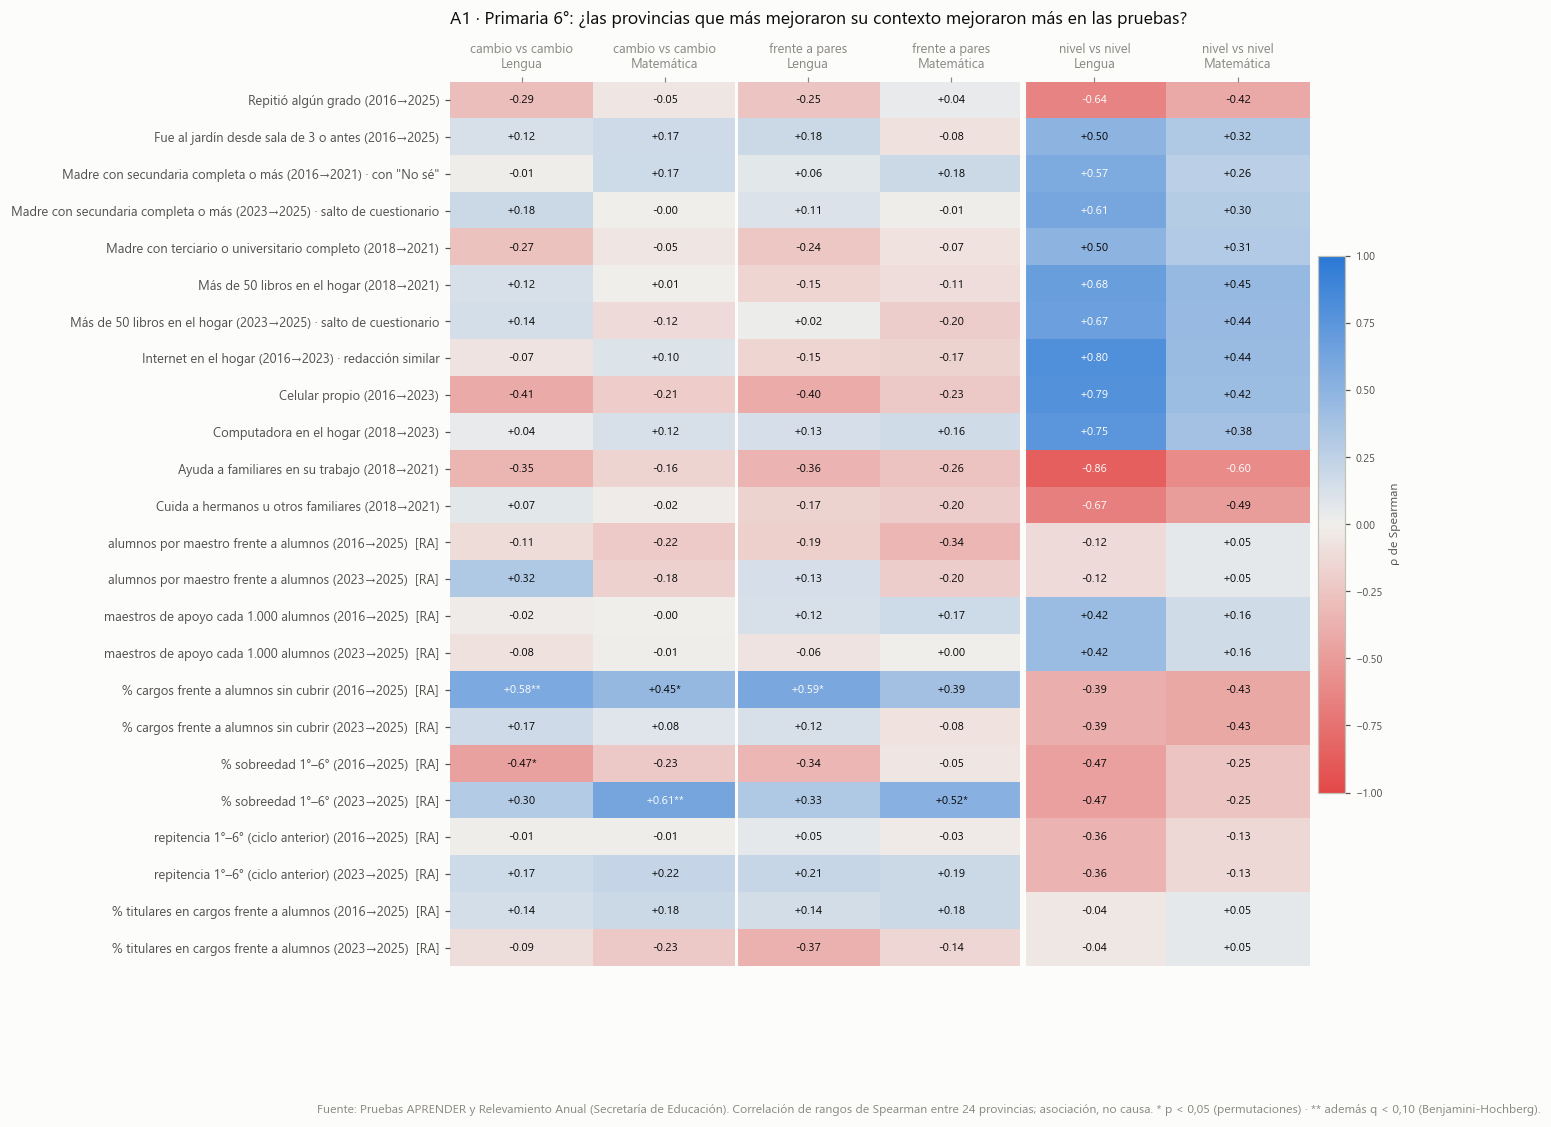

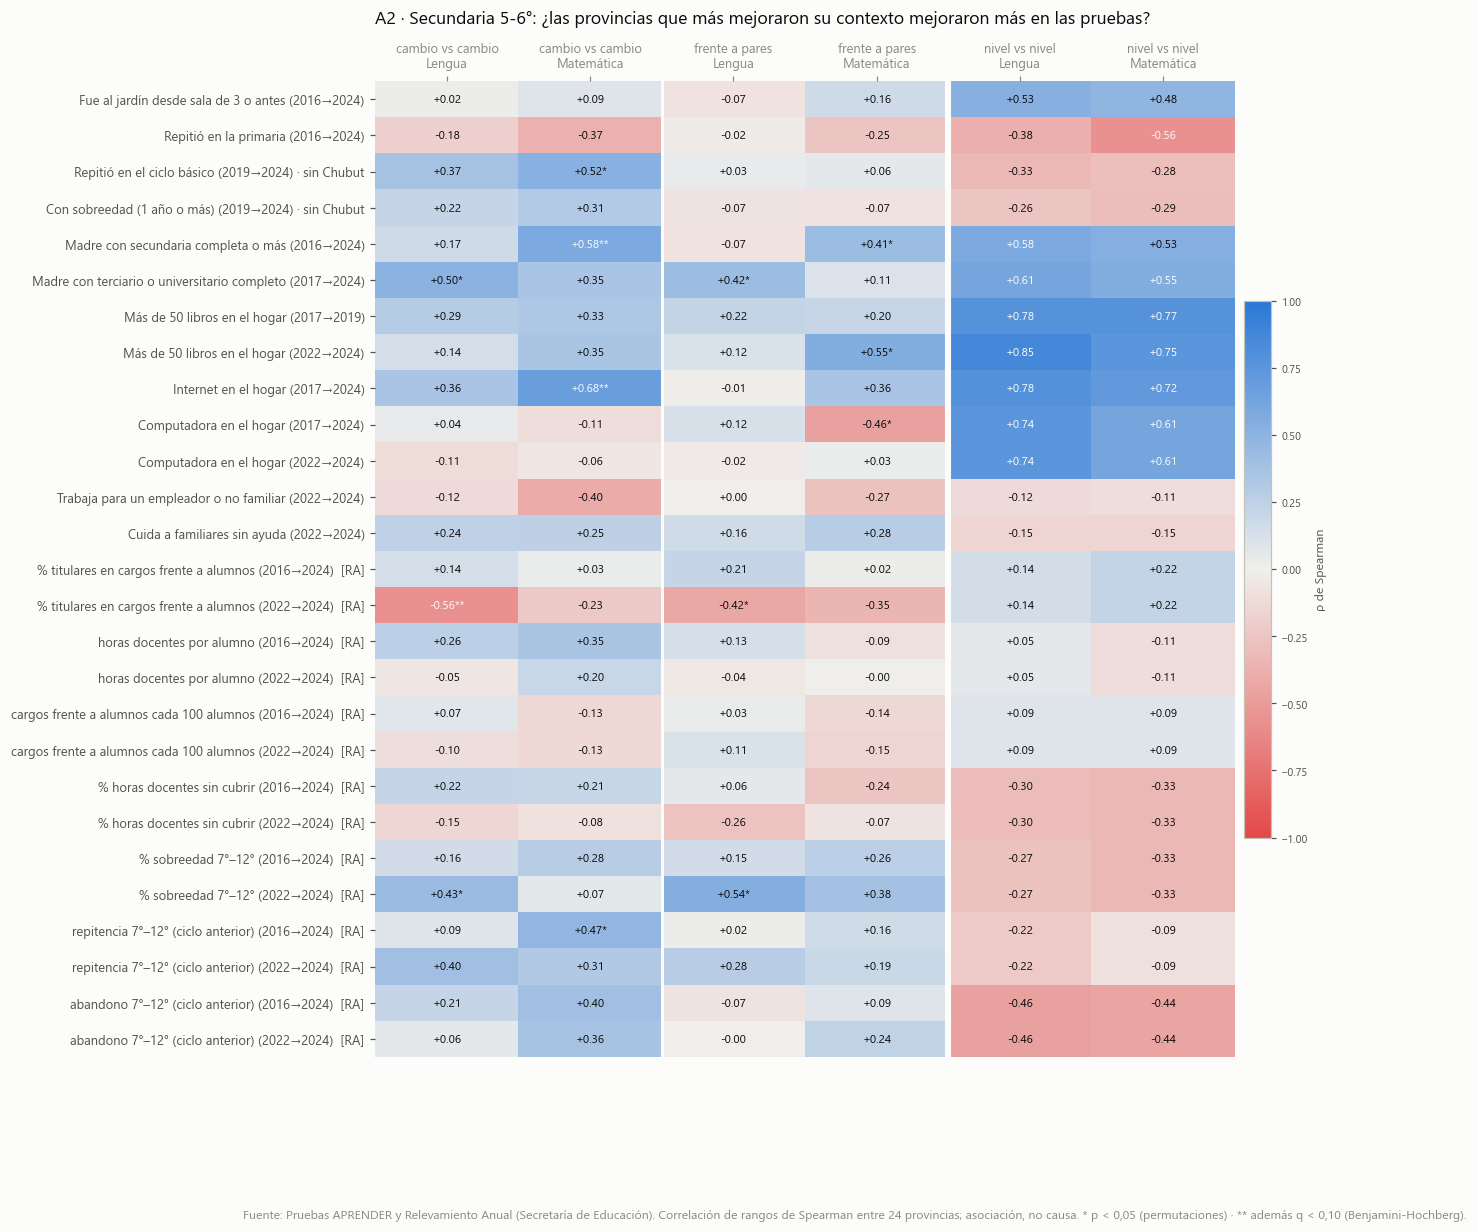

In [5]:
COLS = [('rho_cambio', 'Lengua'), ('rho_cambio', 'Matematica'), ('rho_frente_pares', 'Lengua'), ('rho_frente_pares', 'Matematica'),
        ('rho_nivel_final', 'Lengua'), ('rho_nivel_final', 'Matematica')]
ETQ_COLS = ['cambio vs cambio\nLengua', 'cambio vs cambio\nMatemática', 'frente a pares\nLengua', 'frente a pares\nMatemática',
            'nivel vs nivel\nLengua', 'nivel vs nivel\nMatemática']
def marca(fila, medida, area):
    if medida == 'rho_cambio':
        p, q = fila[('p_cambio', area)], fila[('q_cambio', area)]
        return '**' if (p < 0.05 and q < 0.10) else '*' if p < 0.05 else ''
    if medida == 'rho_frente_pares':
        p = RES.set_index(['cohorte', 'indicador', 'ventana', 'area']).loc[(fila.name[0], fila.name[2], fila.name[3], area), 'p_frente_pares']
        return '*' if p < 0.05 else ''
    return ''

for i, coh in enumerate(COHORTES, start=1):
    t = ANCHO.loc[coh]
    t.index = pd.MultiIndex.from_tuples([(coh,) + k for k in t.index])
    m = t[COLS].values.astype(float)
    etq = [f"{k[2]} ({k[3]})" + (f" · {k[4]}" if k[4] else '') + ('  [RA]' if k[1] == 'Relevamiento Anual' else '') for k in t.index]
    fig, ax = plt.subplots(figsize=(10.5, 0.36 * len(t) + 1.8))
    im = ax.imshow(m, cmap=DIVERGENTE, norm=TwoSlopeNorm(0, -1, 1), aspect='auto')
    ax.set_xticks(range(len(COLS))); ax.set_xticklabels(ETQ_COLS, fontsize=8.5); ax.xaxis.tick_top()
    ax.set_yticks(range(len(t))); ax.set_yticklabels(etq, fontsize=8.5)
    ax.axvline(3.5, color=SUPERFICIE, lw=4); ax.axvline(1.5, color=SUPERFICIE, lw=2)
    for r_ in range(len(t)):
        fila = t.iloc[r_]; fila.name = t.index[r_]
        for c_, (med, area) in enumerate(COLS):
            v = m[r_, c_]
            ax.text(c_, r_, f'{v:+.2f}{marca(fila, med, area)}', ha='center', va='center', fontsize=7.5,
                    color=SUPERFICIE if abs(v) > 0.55 else TINTA)
    ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
    cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.01); cb.set_label('ρ de Spearman', fontsize=8); cb.ax.tick_params(labelsize=7)
    ax.set_title(f'A{i} · {coh}: ¿las provincias que más mejoraron su contexto mejoraron más en las pruebas?', loc='left', fontsize=11.5, pad=38)
    nota(fig, FUENTE + ' * p < 0,05 (permutaciones) · ** además q < 0,10 (Benjamini-Hochberg).')
    guardar(fig, f'A{i}_correlaciones_{"primaria" if i == 1 else "secundaria"}'); plt.show()

---
## B · Las asociaciones más fuertes, provincia por provincia
Diagramas de dispersión **cambio vs cambio**: las tres señales de hogar en Secundaria, la correlación más alta de Primaria
y dos indicadores docentes (que no muestran relación). Cada punto es una provincia; las líneas grises marcan el cambio
mediano. La tabla lista las 12 comparaciones con mayor |ρ|.

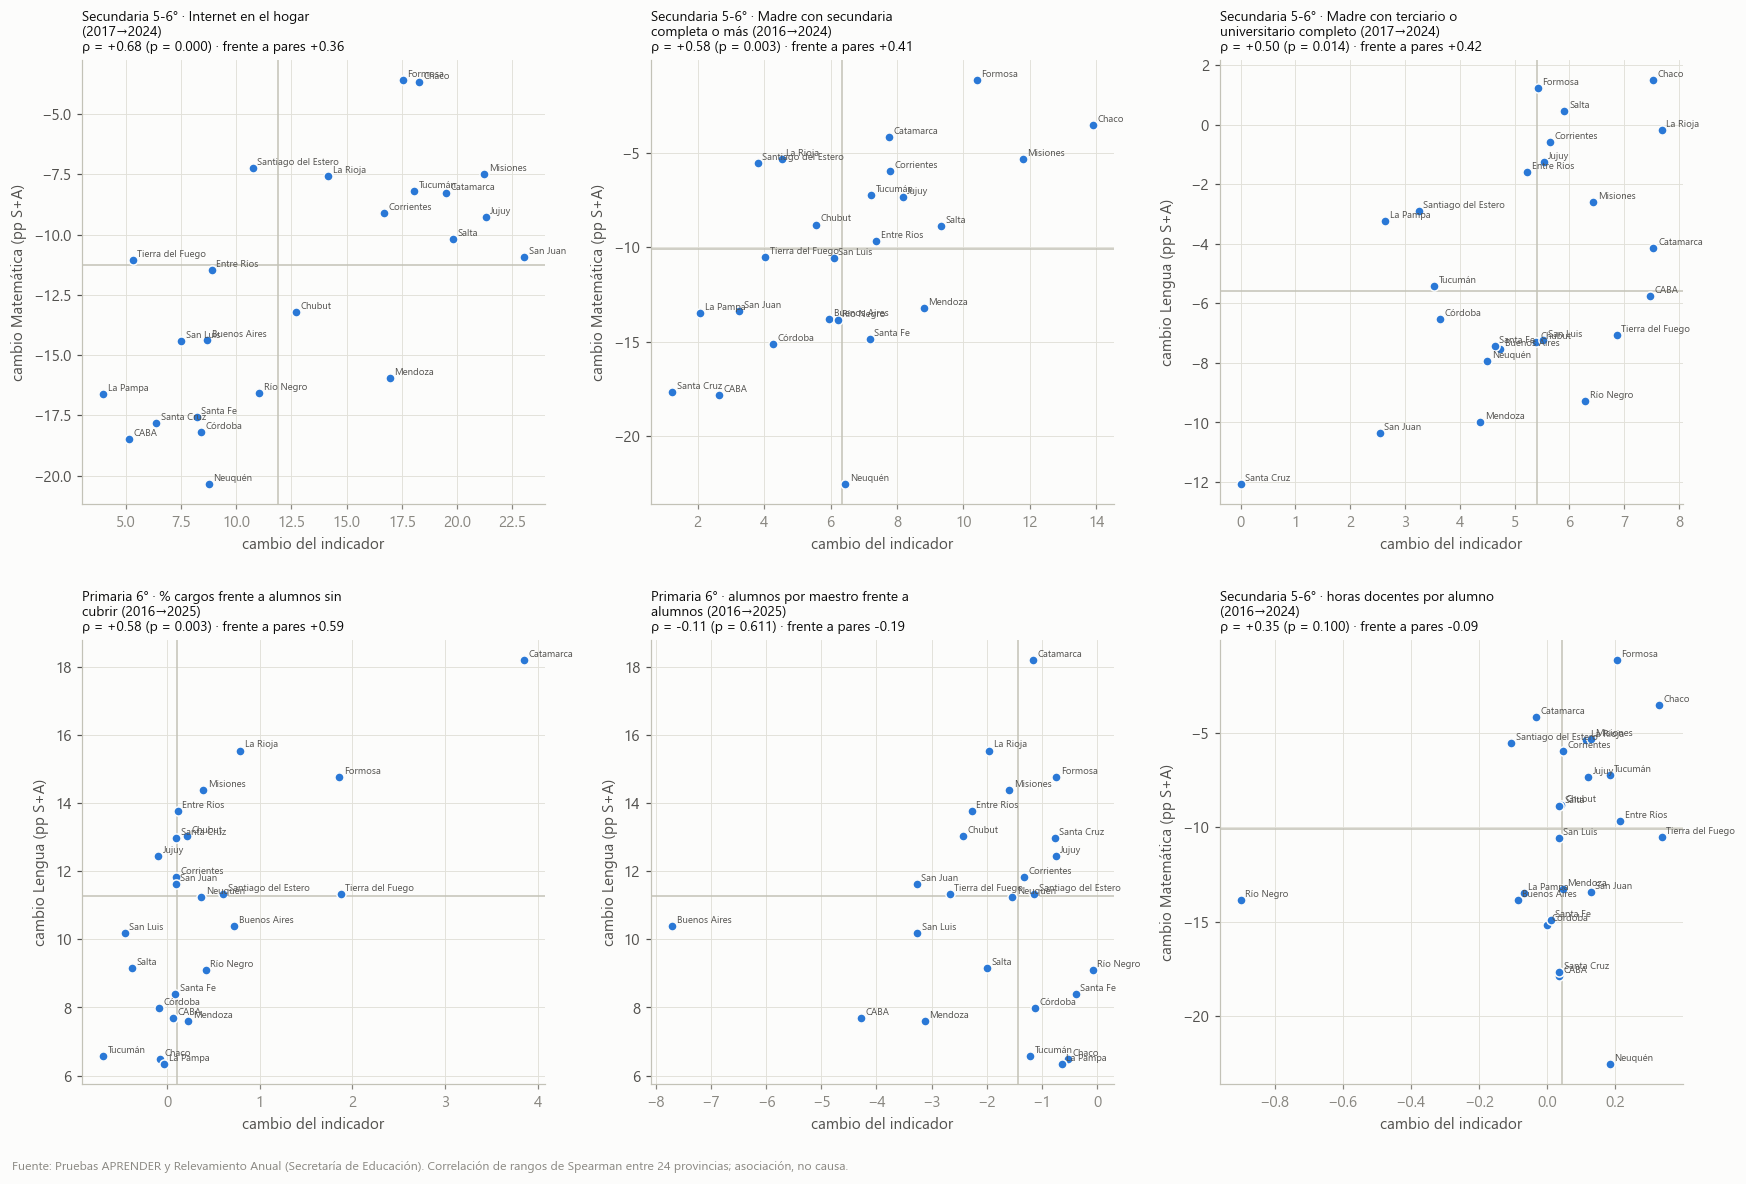

,cohorte,indicador,ventana,area,rho_cambio,p_cambio,q_cambio,rho_frente_pares,rho_nivel_final
59,Secundaria 5-6°,Internet en el hogar,2017→2024,Matematica,0.678,0.000,0.031,0.358,0.718
39,Primaria 6°,% sobreedad 1°–6°,2023→2025,Matematica,0.610,0.002,0.082,0.523,-0.255
53,Secundaria 5-6°,Madre con secundaria completa o más,2016→2024,Matematica,0.582,0.002,0.082,0.415,0.532
32,Primaria 6°,% cargos frente a alumnos sin cubrir,2016→2025,Lengua,0.581,0.003,0.082,0.595,-0.389
100,Secundaria 5-6°,% titulares en cargos frente a alumnos,2022→2024,Lengua,-0.559,0.004,0.088,-0.423,0.144
63,Secundaria 5-6°,Repitió en el ciclo básico,2019→2024,Matematica,0.516,0.014,0.204,0.055,-0.284
54,Secundaria 5-6°,Madre con terciario o universitario completo,2017→2024,Lengua,0.503,0.014,0.204,0.417,0.613
91,Secundaria 5-6°,repitencia 7°–12° (ciclo anterior),2016→2024,Matematica,0.474,0.020,0.259,0.158,-0.086
36,Primaria 6°,% sobreedad 1°–6°,2016→2025,Lengua,-0.468,0.024,0.267,-0.337,-0.472
33,Primaria 6°,% cargos frente a alumnos sin cubrir,2016→2025,Matematica,0.454,0.026,0.267,0.390,-0.430


In [6]:
def dispersion(ax, coh, nombre, ventana, area):
    t = pares[(coh, nombre, ventana, area)]
    ax.axvline(t.cambio_indicador.median(), color=EJE, lw=1); ax.axhline(t.cambio_desempeno.median(), color=EJE, lw=1)
    ax.scatter(t.cambio_indicador, t.cambio_desempeno, s=36, color=AZUL, edgecolor=SUPERFICIE, linewidth=1, zorder=3)
    for prov, fila in t.iterrows():
        ax.annotate(prov, (fila.cambio_indicador, fila.cambio_desempeno), xytext=(3, 2), textcoords='offset points', fontsize=6.3, color=TINTA_2)
    f = RES[(RES.cohorte == coh) & (RES.indicador == nombre) & (RES.ventana == ventana) & (RES.area == area)].iloc[0]
    ax.set_title(textwrap.fill(f'{coh} · {nombre} ({ventana})', 44) + f'\nρ = {f.rho_cambio:+.2f} (p = {f.p_cambio:.3f}) · frente a pares {f.rho_frente_pares:+.2f}',
                 loc='left', fontsize=9)
    ax.set_xlabel('cambio del indicador'); ax.set_ylabel(f'cambio {"Lengua" if area == "Lengua" else "Matemática"} (pp S+A)')

top = RES.assign(a=RES.rho_cambio.abs()).sort_values('a', ascending=False)
# Las señales de hogar en Secundaria, la correlación más alta de Primaria y los indicadores docentes (sin relación)
sel = [('Secundaria 5-6°', 'Internet en el hogar', '2017→2024', 'Matematica'),
       ('Secundaria 5-6°', 'Madre con secundaria completa o más', '2016→2024', 'Matematica'),
       ('Secundaria 5-6°', 'Madre con terciario o universitario completo', '2017→2024', 'Lengua'),
       ('Primaria 6°', '% cargos frente a alumnos sin cubrir', '2016→2025', 'Lengua'),
       ('Primaria 6°', 'alumnos por maestro frente a alumnos', '2016→2025', 'Lengua'),
       ('Secundaria 5-6°', 'horas docentes por alumno', '2016→2024', 'Matematica')]
fig, axs = plt.subplots(2, 3, figsize=(16, 10.5))
for ax, k in zip(axs.flat, sel):
    dispersion(ax, *k)
fig.tight_layout(h_pad=2.5)
nota(fig, FUENTE)
guardar(fig, 'B1_dispersion_principales'); plt.show()
display(RES.loc[top.index[:12], ['cohorte', 'indicador', 'ventana', 'area', 'rho_cambio', 'p_cambio', 'q_cambio', 'rho_frente_pares', 'rho_nivel_final']].round(3))

---
## C · Lectura de resultados (corrida 2026-09-16)

**Respuesta corta:** entre provincias, **mejorar el contexto no se tradujo de forma clara en mejores resultados**. El
contexto del hogar se asocia **muy fuerte con el nivel** (dónde se rinde mejor), pero sus **cambios** casi no se asocian
con los cambios de desempeño. En recursos docentes no aparece relación.

**Cuánto es azar.** De 102 comparaciones cambio vs cambio, 11 dan p < 0,05 (por azar se esperaban ≈ 5) y 5 resisten la
corrección por comparaciones múltiples (q < 0,10). De esas 5, solo las de Secundaria tienen una lectura coherente.

**1. Secundaria: señal débil en la composición del hogar, sobre todo en Matemática.**
- Internet en el hogar (2017→2024): ρ +0,68 con el cambio en Matemática (q 0,03) y +0,36 en Lengua. **Frente a pares
  baja a +0,36**: buena parte es efecto *piso*. Matemática cayó en todas las provincias, y cayó menos donde ya era baja
  (Formosa, Chaco, Misiones), que es también donde más creció internet.
- Madre con secundaria completa o más (2016→2024): ρ +0,58 en Matemática (q 0,08); frente a pares +0,41.
- Madre con terciario o universitario completo (2017→2024): ρ +0,50 en Lengua (p 0,01); frente a pares +0,42.
- Más de 50 libros (2022→2024): ρ +0,35 en Matemática y **+0,55 frente a pares** (coincide con el 03, ρ +0,57).
- **Cómo leerlo:** en Secundaria rinden quienes llegan al último año. Si mejora el nivel educativo de esos hogares,
  puede mejorar el resultado **sin que la escuela enseñe más** (cambio de composición). Además, la repitencia en el ciclo
  básico da ρ +0,52 en bruto y +0,06 frente a pares: era solo convergencia.
- Computadora en el hogar (2017→2024): ρ −0,11 en bruto y **−0,46 frente a pares** en Matemática, sentido contrario al
  esperable.

**2. Recursos docentes (Relevamiento Anual): sin relación consistente.**
- Primaria, alumnos por maestro frente a alumnos (2016→2025): ρ −0,11 en Lengua y −0,22 en Matemática. El signo es el
  esperable (menos alumnos por maestro, más mejora), pero la relación es débil. Maestros de apoyo, % de titulares y
  repitencia: ρ ≈ 0.
- Secundaria, horas docentes por alumno (2016→2024): ρ +0,26 / +0,35, pero ≈ 0 frente a pares. Cargos cada 100 alumnos
  y % de horas sin cubrir: ρ entre −0,15 y +0,22.
- Las correlaciones "significativas" van al revés de lo esperable o cambian de signo según la ventana: % de cargos sin
  cubrir en Primaria (2016→2025) ρ +0,58 en Lengua, empujado por Catamarca (+3,9 pp de vacantes y +18 pp en Lengua);
  % de titulares en Secundaria (2022→2024) ρ −0,56; sobreedad RA en Primaria +0,61 (2023→2025) pero −0,47 (2016→2025).
  **No se interpretan** como hallazgos.
- **Control de calidad RA:** en Buenos Aires los alumnos por maestro frente a alumnos pasan de ≈ 26 (estables hasta 2022)
  a 18,4 en 2025. Parece un cambio en cómo se informan los cargos, no una incorporación masiva de maestros.

**3. Primaria: nada consistente en el cuestionario.** Jardín, repitencia, educación de la madre, libros, internet,
computadora, celular y trabajo dan |ρ| ≤ 0,41, y ninguno se sostiene en Lengua y Matemática a la vez.

**4. Niveles (referencia).** En el año final, las provincias con más libros (Secundaria ρ +0,85 / +0,75), internet
(+0,78 / +0,72), computadora (+0,74 / +0,61) y madres más educadas (+0,58 / +0,53) rinden más; donde más chicos de Primaria
ayudan en el trabajo familiar, rinden menos (−0,86 / −0,60). Los indicadores docentes casi no se asocian con el nivel
(alumnos por maestro −0,12 / +0,05).

**Qué haría falta para ir más lejos.** Cruces **por estudiante** con los microdatos 2024 (desempeño × educación de la madre,
libros, computadora; Primaria 3° × NSE de la escuela) y fuentes externas sobre participación en la prueba, días de clase,
programas de alfabetización y régimen académico por provincia.

---
## D · Descargar gráficos y tablas
Guarda las tablas en `asociaciones_desempeno.xlsx` dentro de `graficos_asociaciones/`, comprime la carpeta en un `.zip`
y, en **Colab**, **lo descarga**.

In [7]:
hojas = {'correlaciones': RES.round(4),
         'correlaciones_ancho': ANCHO.round(3),
         'desempeno_provincias': DES.round(3)}
filas_ind = []
for (coh, tema, nombre, y0, y1, nota_v), v in ind_prov.items():
    filas_ind.append(pd.DataFrame({'inicial': v[y0], 'final': v[y1]}).assign(cohorte=coh, tema=tema, indicador=nombre, ventana=f'{y0}→{y1}', nota=nota_v))
hojas['indicadores_provincias'] = (pd.concat(filas_ind).rename_axis('provincia').reset_index()
                                   .assign(cambio=lambda t: t.final - t.inicial).round(3)
                                   .set_index(['cohorte', 'tema', 'indicador', 'ventana', 'nota', 'provincia']))
ruta_xlsx = os.path.join(GRAF, 'asociaciones_desempeno.xlsx')
with pd.ExcelWriter(ruta_xlsx, engine='openpyxl') as xw:
    for nombre, t in hojas.items():
        t = t.copy()
        if isinstance(t.columns, pd.MultiIndex):
            t.columns = [' | '.join(map(str, c)) for c in t.columns]
        t.to_excel(xw, sheet_name=nombre[:31])
print('Archivos a descargar:')
for n in sorted(os.listdir(GRAF)): print('  -', n)
zip_path = shutil.make_archive(os.path.join(os.path.dirname(GRAF), 'graficos_asociaciones'), 'zip', GRAF)
print('\nZIP:', zip_path, f'({os.path.getsize(zip_path)/1e6:.1f} MB)')
if in_colab():
    from google.colab import files
    files.download(zip_path)
    print('Descargando el zip...')
else:
    print('Entorno local: los archivos quedan en', GRAF)

Archivos a descargar:
  - A1_correlaciones_primaria.png
  - A2_correlaciones_secundaria.png
  - B1_dispersion_principales.png
  - asociaciones_desempeno.xlsx

ZIP: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_asociaciones.zip (2.3 MB)
Entorno local: los archivos quedan en C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_asociaciones
